In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tabulate import tabulate

### Training a Fully Connected Deep Network for Classification Tasks

An example of simple MNIST Digit Classification task with only dense layers.

_We choose **2 hidden layers** with 32 and 16 neurons in each._

In [2]:
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.mnist.load_data()

print ('check shape of train data: ', train_x.shape, train_y.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
check shape of train data:  (60000, 28, 28) (60000,)


In [3]:
choose_image_index = 67

pixel_vals = train_x[choose_image_index]
print (pixel_vals.shape)

table = tabulate(pixel_vals, tablefmt="grid")

# Print the table
print(table)


print ('corresponding label: ', train_y[choose_image_index])

(28, 28)
+---+---+---+---+---+---+---+---+---+---+-----+-----+-----+-----+-----+-----+-----+-----+----+-----+---+---+---+---+---+---+---+---+
| 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |  0 |   0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
+---+---+---+---+---+---+---+---+---+---+-----+-----+-----+-----+-----+-----+-----+-----+----+-----+---+---+---+---+---+---+---+---+
| 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |  0 |   0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
+---+---+---+---+---+---+---+---+---+---+-----+-----+-----+-----+-----+-----+-----+-----+----+-----+---+---+---+---+---+---+---+---+
| 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |  0 |   0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
+---+---+---+---+---+---+---+---+---+---+-----+-----+-----+-----+-----+-----+-----+-----+----+-----+---+---+---+---+---+---+---+---+
| 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |   0 |   0 |   0 | 

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

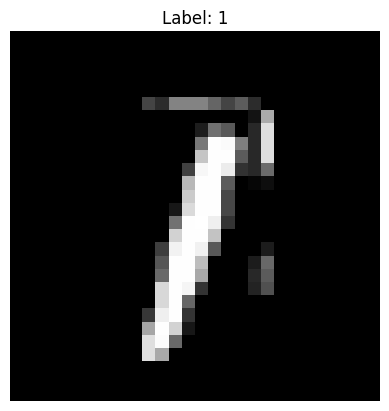

In [4]:
plt.imshow(train_x[choose_image_index], cmap='gray')
plt.title('Label: %s'%(train_y[choose_image_index]))
plt.axis('off')

### Pre-Processing Data




* In deep learning, data is stored in tensors. The term tensor applies to a scalar (0D tensor), vector (1D tensor), matrix (2D tensor), and a multi-dimensional tensor.

* The rest code computes the image dimensions, input_size of the first Dense layer and scales each pixel value from 0 to 255 to range from 0.0 to 1.0.


* This simplest model is based on fully connected layers (also called a multi-layer perceptron). For Dense layers, we cannot input an image in its original format (as a 2D or 3D array).

  So we first need to flatten (or reshape the array). Therefore, the input is expected to be a 1D tensor. So, x_train and x_test are reshaped to `[60000, 28 28]` and `[10000, 28 28]`, respectively.






In [5]:
## what flattening does a simple example

x = np.array([[2, 3], [4, 5], [6, 7]])
print ('check array before flattening: ', '\n', x)
print (x.shape)
x_flat = x.reshape(x.shape[0]*x.shape[1])
print ('check array after flattening: ', '\n', x_flat)

check array before flattening:  
 [[2 3]
 [4 5]
 [6 7]]
(3, 2)
check array after flattening:  
 [2 3 4 5 6 7]


In [ ]:
train_x.shape

(60000, 28, 28)

In [6]:
# resize and normalize
train_x_re = np.reshape(train_x, (train_x.shape[0], train_x.shape[1]*train_x.shape[2]))
train_x_re = train_x_re.astype('float32') / 255

test_x_re = np.reshape(test_x, (test_x.shape[0], test_x.shape[1]*test_x.shape[2]))
test_x_re = test_x_re.astype('float32') / 255

In [7]:
## check shapes after

print (train_x_re.shape, '\n', test_x_re.shape)

(60000, 784) 
 (10000, 784)


In [8]:
batch_size = 128
hidden_units1, hidden_units2 = 32, 16
## number of unique labels in data

# compute the number of labels
num_labels = len(np.unique(train_y)) # just 10 different numbers from 0 to 9.


In [9]:
from tensorflow.keras.layers import Dense # this does everything related to a fully connected layer
# we only need to specify the number of neurons
# and the activation function

In [10]:
### use Sequential to define a model with TensorFlow

model = tf.keras.models.Sequential()
model.add(Dense(hidden_units1, activation='relu', input_shape=(28 * 28,)))
model.add(Dense(hidden_units2, activation='relu', input_shape=(28 * 28,)))
model.add(Dense(num_labels, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,818 (100.85 KB)

 Trainable params: 25,818 (100.85 KB)

 Non-trainable params: 0 (0.00 B)

### How Do We Justify the Number of Parameters?

1. Input data shape = 784, i.e. 784 Neurons (Nodes)

2. 1st layer has 32 Nodes; Every node in this layer is connected to every input nodes.  

  2.1. So total weights $784 \times 32 = 25088 $

  2.2. Total biases 32

  2.3. Total params : weights + biases $25088 + 32 = 25120$

Similarly, we can calculate for every other layers.   

In [12]:
layer_weights1 = train_x_re.shape[1]*32
print (layer_weights1)

25088


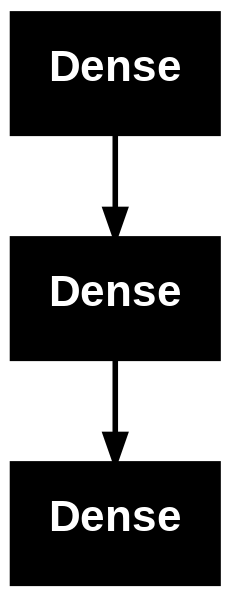

In [13]:
tf.keras.utils.plot_model(model)

### One Hot Encoding of Labels




* At this point, the labels are in digits format, 0 to 9.

* This sparse scalar representation of labels is not suitable for the neural network prediction layer that outputs probabilities per class.

  * say our network wants to predict 1, we want our output as `[0, 0.86, 0, 0, 0, 0, 0, 0.13, 0, 0.01]`

  * Then we can interpret this as class probabilities. 1 is most probable!  

* A more suitable format is called a one-hot vector, a 10-dim vector with all elements 0, except for the index of the digit class.

* For example, if the label is 2, the equivalent one-hot vector is `[0,0,1,0,0,0,0,0,0,0]`.

* The following lines convert each label into a one-hot vector:


In [14]:
###

from tensorflow.keras.utils import to_categorical

train_y_cat = to_categorical(train_y)
test_y_cat = to_categorical(test_y)

print ('check examples before and after: ', train_y[choose_image_index], '\n', train_y_cat[choose_image_index])

check examples before and after:  1 
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


In [15]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                25120     
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 10)                170       
                                                                 
Total params: 25,818
Trainable params: 25,818
Non-trainable params: 0
_________________________________________________________________


### What is Categorical Cross-Entropy


Consider a 3 class problem for simplicity; (MNIST has 10 classes)

Say our true label is:  $y_t = [0, \, 1,\,   0]$

Our predicted label is:  $y_p = [0.31, \, 0.53,\,   0.15]$

Cross entropy loss is defined as $CE = - \sum \limits_{i=1}^N y_{t_i}\, \log (y_{p_i})$

In [16]:
def ex_CE(y_t, y_p):
  '''
  simple and short demo for cross entropy loss
  '''
  return np.sum(y_t * np.log(y_p + 1e-15))

y_t = np.array([[0], [1], [0]])
y_p = np.array([[0.31], [0.53], [0.15]])

ce_loss = ex_CE(y_t, y_p)

print ('check cross entropy loss: ', ce_loss)

check cross entropy loss:  -0.6348782724359676


In [17]:
# fit the model

history = model.fit(train_x_re, train_y_cat,
                    epochs=20, batch_size=batch_size)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7161 - loss: 0.9691
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9276 - loss: 0.2511
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9419 - loss: 0.1969
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9530 - loss: 0.1639
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9590 - loss: 0.1428
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9633 - loss: 0.1291
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9674 - loss: 0.1146
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9691 - loss: 0.1056
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9705 - loss: 0.1011
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9748 - loss: 0.0879
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9744 - loss: 0.0875
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [18]:
loss, acc = model.evaluate(test_x_re, test_y_cat, batch_size=batch_size)
print("\nTest accuracy: %.1f%%" % (100.0 * acc))


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9639 - loss: 0.1463

Test accuracy: 96.8%


### how does the loss behave?

Let's plot the loss as a function of training steps

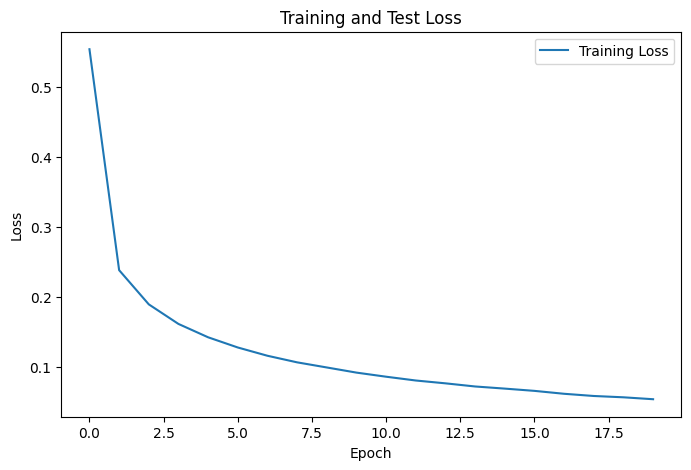

In [19]:

# Save the metrics.
metrics = history.history


# Save the loss values.
training_loss_list = metrics['loss']


# Plot the training and test loss.
x = np.arange(0, len(training_loss_list), 1)


fig = plt.figure(figsize=(8, 5))
plt.title('Training and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(x, training_loss_list, label='Training Loss')
plt.legend()
plt.show()



### Let's Check Some Predictions

In [20]:
predictions = model.predict(test_x_re)

print ('what is predictions: ', type(predictions))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
what is predictions:  <class 'numpy.ndarray'>


In [21]:
print ('shape of predictions: ', predictions.shape)

shape of predictions:  (10000, 10)


In [31]:
rand_indices = np.random.randint(0, 10000, 16)
print (rand_indices)

[3813 2307 6707 7164 2269 2795  836 2018  757 9535 2159 4203 2661 7232
 9549 6571]


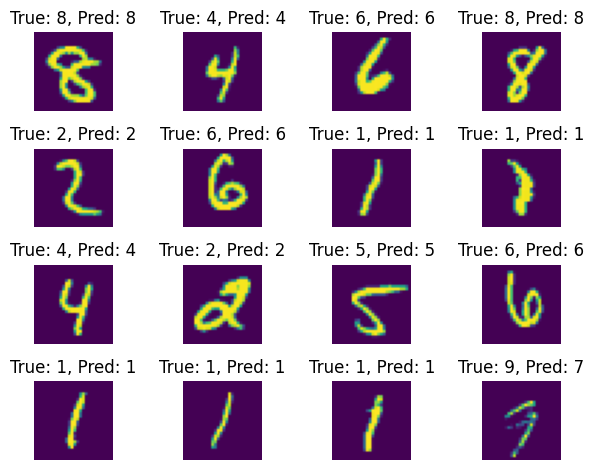

In [32]:
fig, axes = plt.subplots(4, 4)

# iterate over the axes and plot ims
for i, ax in enumerate(axes.flat):
    # load ims and plot it on the current axis
    image = test_x[rand_indices[i]]
    ax.set_title('True: %s, Pred: %s'%(test_y[rand_indices[i]], np.argmax(predictions[rand_indices[i]])))
    ax.imshow(image)
    ax.axis('off')

# adjust the space between subplts
plt.tight_layout()

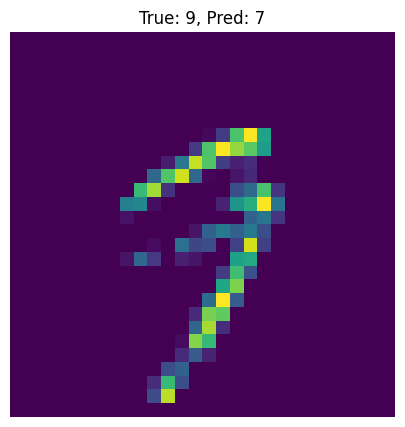

In [33]:
## one mismatch
fig=plt.figure(figsize=(8, 5))
image = test_x[6571]  #
plt.title('True: %s, Pred: %s'%(test_y[6571], np.argmax(predictions[6571])))
plt.imshow(image)
plt.axis('off')
plt.show()

In [34]:
predictions[6571]

array([1.8198550e-04, 2.1574462e-03, 4.0092421e-04, 3.2827458e-03,
       1.3229768e-04, 3.0073346e-04, 5.2102656e-08, 8.2788831e-01,
       3.3418811e-04, 1.6532126e-01], dtype=float32)